In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install SimpleITK tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 11.2 MB/s eta 0:00:00


In [ ]:
import os
import gc
import zipfile
import shutil
import subprocess
from pathlib import Path
from urllib.parse import quote

import pandas as pd
import numpy as np
import SimpleITK as sitk
from tqdm import tqdm

In [ ]:
# LUNA16 Zenodo records
PART1_RECORD = "3723295"   # subset0 to subset6 + annotations/candidates
PART2_RECORD = "4121926"   # subset7 to subset9

subset_record = {
    "subset0.zip": PART1_RECORD,
    "subset1.zip": PART1_RECORD,
    "subset2.zip": PART1_RECORD,
    "subset3.zip": PART1_RECORD,
    "subset4.zip": PART1_RECORD,
    "subset5.zip": PART1_RECORD,
    "subset6.zip": PART1_RECORD,
    "subset7.zip": PART2_RECORD,
    "subset8.zip": PART2_RECORD,
    "subset9.zip": PART2_RECORD,
}

In [ ]:
#Function to download any file from Zenodo
def zenodo_download_url(record_id, filename):
    filename_encoded = quote(filename)
    return f"https://zenodo.org/records/{record_id}/files/{filename_encoded}?download=1"


def download_from_zenodo(record_id, filename, out_dir="/content"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / filename
    url = zenodo_download_url(record_id, filename)

    print(f"Downloading: {filename}")
    print(f"Saving to: {out_path}")

    cmd = [
        "wget",
        "-c",                      # resume if interrupted
        "--progress=bar:force",
        "-O",
        str(out_path),
        url
    ]

    subprocess.run(cmd, check=True)

    return str(out_path)

In [ ]:
#Load annotations.csv directly from Zenodo
annotations_url = zenodo_download_url(PART1_RECORD, "annotations.csv")

annotations = pd.read_csv(annotations_url)

print(annotations.head())
print(annotations.shape)

                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...  -24.013824  192.102405   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...    2.441547  172.464881   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  
3 -391.081276     8.143262  
4 -405.493732    18.545150  
(1186, 5)


Run from this for each subset


In [ ]:
#Download one subset only
WORK_DIR = "/content/luna_work"
os.makedirs(WORK_DIR, exist_ok=True)

subset_name = "subset0.zip"
record_id = subset_record[subset_name]

zip_path = download_from_zenodo(record_id, subset_name, WORK_DIR)

Downloading: subset0.zip
Saving to: /content/luna_work/subset0.zip


In [ ]:
#Extract the subset
extract_dir = "/content/luna_work/subset0"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files ready.")

Extracted files ready.


In [ ]:
#Check .mhd files:
import glob

mhd_files = glob.glob(extract_dir + "/**/*.mhd", recursive=True)

print("Total .mhd files:", len(mhd_files))
print(mhd_files[:3])

Total .mhd files: 89
['/content/luna_work/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.395623571499047043765181005112.mhd', '/content/luna_work/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.141069661700670042960678408762.mhd', '/content/luna_work/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.154677396354641150280013275227.mhd']


In [ ]:
print(mhd_files[0])

/content/luna_work/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.395623571499047043765181005112.mhd


In [ ]:
#Set paths
SUBSET_DIR = Path("/content/luna_work/subset0")

# processed output will be saved in Google Drive
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

PATCH_SIZE = 64
RANDOM_STATE = 42

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Subset folder exists:", SUBSET_DIR.exists())
print("Output folder:", OUTPUT_ROOT)

Subset folder exists: True
Output folder: /content/drive/MyDrive/LUNA16_processed_64


In [ ]:
mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Total CT scans found in subset0:", len(mhd_files))
print(mhd_files[:3])

Total CT scans found in subset0: 89
[PosixPath('/content/luna_work/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.395623571499047043765181005112.mhd'), PosixPath('/content/luna_work/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.141069661700670042960678408762.mhd'), PosixPath('/content/luna_work/subset0/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.154677396354641150280013275227.mhd')]


In [ ]:
#Load annotations.csv and candidates_V2
PART1_RECORD = "3723295"

def zenodo_url(record_id, filename):
    return f"https://zenodo.org/records/{record_id}/files/{filename}?download=1"

annotations_url = zenodo_url(PART1_RECORD, "annotations.csv")
annotations = pd.read_csv(annotations_url)

print("Annotations shape:", annotations.shape)
print(annotations.head())

Annotations shape: (1186, 5)
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...  -24.013824  192.102405   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...    2.441547  172.464881   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  
3 -391.081276     8.143262  
4 -405.493732    18.545150  


In [ ]:
WORK_DIR = Path("/content/luna_work")
candidates_zip = WORK_DIR / "candidates_V2.zip"
candidates_dir = WORK_DIR / "candidates_V2"

if not candidates_zip.exists():
    !wget -c -O "{candidates_zip}" "https://zenodo.org/records/3723295/files/candidates_V2.zip?download=1"

candidates_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(candidates_zip, "r") as zip_ref:
    zip_ref.extractall(candidates_dir)

csv_files = list(candidates_dir.rglob("*.csv"))
print(csv_files)

candidates = pd.read_csv(csv_files[0])

print("Candidates shape:", candidates.shape)
print(candidates.head())
print(candidates["class"].value_counts())

--2026-05-23 21:17:38--  https://zenodo.org/records/3723295/files/candidates_V2.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.48.75, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11439452 (11M) [application/octet-stream]
Saving to: ‘/content/luna_work/candidates_V2.zip’

/content/luna_work/ 100%[===================>]  10.91M  5.27MB/s    in 2.1s    

2026-05-23 21:17:41 (5.27 MB/s) - ‘/content/luna_work/candidates_V2.zip’ saved [11439452/11439452]

[PosixPath('/content/luna_work/candidates_V2/candidates_V2.csv')]
Candidates shape: (754975, 5)
                                           seriesuid     coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  68.420000  -74.480000   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -95.209361  -91.809406   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -24.766755 -120.379294   
3  

In [ ]:
#Create patient-level Train/Val/Test split
all_uids = sorted(candidates["seriesuid"].unique())

positive_uids = set(annotations["seriesuid"].unique())

patient_df = pd.DataFrame({
    "seriesuid": all_uids
})

patient_df["has_nodule"] = patient_df["seriesuid"].isin(positive_uids).astype(int)

print(patient_df.head())
print(patient_df["has_nodule"].value_counts())

                                           seriesuid  has_nodule
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...           1
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840...           0
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...           1
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100530488926...           0
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482...           0
has_nodule
1    601
0    287
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df, temp_df = train_test_split(
    patient_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=patient_df["has_nodule"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["has_nodule"]
)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

split_csv_path = OUTPUT_ROOT / "patient_split.csv"
split_df.to_csv(split_csv_path, index=False)

print(split_df["split"].value_counts())
print("Saved split file:", split_csv_path)

split
train    621
test     134
val      133
Name: count, dtype: int64
Saved split file: /content/drive/MyDrive/LUNA16_processed_64/patient_split.csv


In [ ]:
#Create split map:
split_map = dict(zip(split_df["seriesuid"], split_df["split"]))

In [ ]:
#Make output folders
for split in ["train", "val", "test"]:
    for cls in ["pos", "neg"]:
        folder = OUTPUT_ROOT / split / cls
        folder.mkdir(parents=True, exist_ok=True)

print("Folders created.")

Folders created.


In [ ]:
#Preprocessing helper functions
def resample_to_1mm(image):
    original_spacing = np.array(image.GetSpacing(), dtype=np.float32)
    original_size = np.array(image.GetSize(), dtype=np.int32)

    new_spacing = np.array([1.0, 1.0, 1.0], dtype=np.float32)
    new_size = np.round(original_size * (original_spacing / new_spacing)).astype(np.int32)

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(tuple(new_spacing.tolist()))
    resampler.SetSize([int(x) for x in new_size])
    resampler.SetOutputDirection(image.GetDirection())
    resampler.SetOutputOrigin(image.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(-1000)
    resampler.SetInterpolator(sitk.sitkLinear)

    return resampler.Execute(image)


def normalize_hu(arr, min_hu=-1000, max_hu=400):
    arr = np.clip(arr, min_hu, max_hu)
    arr = (arr - min_hu) / (max_hu - min_hu)
    return arr.astype(np.float32)


def extract_patch_from_world(image, coord_xyz, patch_size=64):
    """
    image: SimpleITK image after resampling
    coord_xyz: [coordX, coordY, coordZ] from csv
    returns: numpy patch with shape [64, 64, 64]
    Origin, Spacing, Direction from the .mhd header are preserved
    explicitly via SetOutputOrigin() in resample_to_1mm(), so
    TransformPhysicalPointToIndex() applies the correct transform:
    voxel = Direction^-1 * (world - Origin) / Spacing  (Point 3)
    """

    try:
        index_xyz = image.TransformPhysicalPointToIndex(
            (float(coord_xyz[0]), float(coord_xyz[1]), float(coord_xyz[2]))
        )
    except Exception:
        return None

    size_xyz = image.GetSize()

    x, y, z = index_xyz

    if x < 0 or y < 0 or z < 0:
        return None

    if x >= size_xyz[0] or y >= size_xyz[1] or z >= size_xyz[2]:
        return None

    arr = sitk.GetArrayFromImage(image)  # z, y, x
    arr = normalize_hu(arr)

    half = patch_size // 2

    # pad so border patches do not fail
    arr_pad = np.pad(
        arr,
        pad_width=((half, half), (half, half), (half, half)),
        mode="constant",
        constant_values=0
    )

    z_p = z + half
    y_p = y + half
    x_p = x + half

    patch = arr_pad[
        z_p-half:z_p+half,
        y_p-half:y_p+half,
        x_p-half:x_p+half
    ]

    if patch.shape != (patch_size, patch_size, patch_size):
        return None

    return patch.astype(np.float32)

In [ ]:
#Function for hard negative sampling
# Point 1: Enforce strict 5-negatives-per-positive ratio
NEG_PER_POS_RATIO = 5

def sample_hard_negatives(uid, pos_count, candidates_df, random_state=42):
    neg_df = candidates_df[
        (candidates_df["seriesuid"] == uid) &
        (candidates_df["class"] == 0)
    ].copy()

    if len(neg_df) == 0:
        return neg_df

    # Point 1: strict ratio — 5 negatives per positive, minimum 5
    n_neg = max(NEG_PER_POS_RATIO, pos_count * NEG_PER_POS_RATIO)
    n_neg = min(n_neg, len(neg_df))  # cap only at available candidates

    neg_df = neg_df.sample(n=n_neg, random_state=random_state)

    return neg_df


# Point 4: Spatial deduplication — remove negatives overlapping true nodules
def filter_negatives_near_nodules(neg_df, pos_df):
    """
    Removes hard negative candidates whose world-coordinate centroid
    falls within the physical radius of any annotated true nodule.
    Prevents label noise from negatives that contain malignant tissue.
    """
    if pos_df.empty or neg_df.empty:
        return neg_df

    nodule_centers = pos_df[["coordX", "coordY", "coordZ"]].values
    nodule_radii = (pos_df["diameter_mm"].values / 2.0)

    keep_mask = []
    for _, neg_row in neg_df.iterrows():
        neg_coord = np.array([neg_row["coordX"], neg_row["coordY"], neg_row["coordZ"]])
        too_close = False
        for idx, nod_center in enumerate(nodule_centers):
            dist = np.linalg.norm(neg_coord - nod_center)
            if dist < nodule_radii[idx]:
                too_close = True
                break
        keep_mask.append(not too_close)

    return neg_df[keep_mask].reset_index(drop=True)


In [ ]:
#Process subset0
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc="Processing subset0"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": "subset0",
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": "subset0",
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / "metadata_subset0.csv"
metadata_df.to_csv(metadata_path, index=False)

print("Preprocessing subset0 completed.")
print("Metadata saved:", metadata_path)
print(metadata_df.head())
print(metadata_df["split"].value_counts())
print(metadata_df["label"].value_counts())

Processing subset0: 100%|██████████| 89/89 [09:42<00:00,  6.54s/it]

Preprocessing subset0 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset0.csv
                                            filepath  \
0  /content/drive/MyDrive/LUNA16_processed_64/tes...   
1  /content/drive/MyDrive/LUNA16_processed_64/tes...   
2  /content/drive/MyDrive/LUNA16_processed_64/tes...   
3  /content/drive/MyDrive/LUNA16_processed_64/tes...   
4  /content/drive/MyDrive/LUNA16_processed_64/tes...   

                                           seriesuid   subset split  label  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.395623571499...  subset0  test      1   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.395623571499...  subset0  test      0   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.395623571499...  subset0  test      0   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.395623571499...  subset0  test      0   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.395623571499...  subset0  test      0   

  class_name  coord_world_X  coord_world_Y  coord_world_Z  diameter_mm  
0       

In [ ]:
#Check output counts
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

train
  Positive patches: 79
  Negative patches: 470
val
  Positive patches: 22
  Negative patches: 120
test
  Positive patches: 11
  Negative patches: 80


In [ ]:
#Check patient leakage
train_uids = set(split_df[split_df["split"] == "train"]["seriesuid"])
val_uids = set(split_df[split_df["split"] == "val"]["seriesuid"])
test_uids = set(split_df[split_df["split"] == "test"]["seriesuid"])

print("Train-Val overlap:", len(train_uids & val_uids))
print("Train-Test overlap:", len(train_uids & test_uids))
print("Val-Test overlap:", len(val_uids & test_uids))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


Total saved patches: 782
Patch path: /content/drive/MyDrive/LUNA16_processed_64/train/neg/1.3.6.1.4.1.14519.5.2.1.6279.6001.277445975068759205899107114231_neg_7.npy
Patch shape: (64, 64, 64)
Min: 0.0 Max: 0.85142857


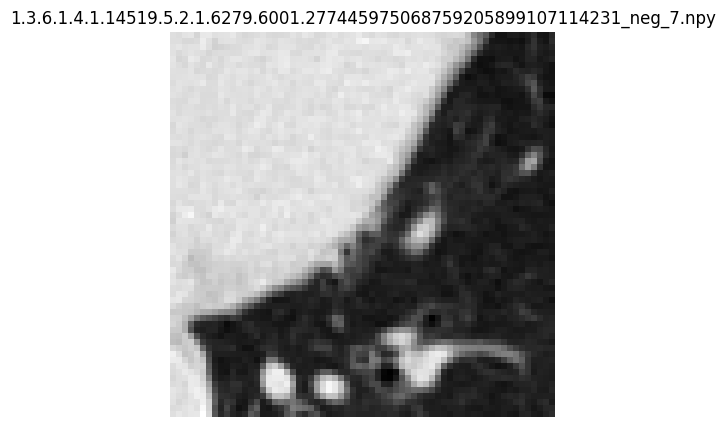

In [ ]:
#Visual sanity check
import matplotlib.pyplot as plt
import random

all_patches = list(OUTPUT_ROOT.rglob("*.npy"))

print("Total saved patches:", len(all_patches))

sample_patch_path = random.choice(all_patches)
patch = np.load(sample_patch_path)

print("Patch path:", sample_patch_path)
print("Patch shape:", patch.shape)
print("Min:", patch.min(), "Max:", patch.max())

middle_slice = patch[PATCH_SIZE // 2]

plt.figure(figsize=(5, 5))
plt.imshow(middle_slice, cmap="gray")
plt.title(sample_patch_path.name)
plt.axis("off")
plt.show()

In [ ]:
!find /content/drive/MyDrive/LUNA16_processed_64 -type f | head

/content/drive/MyDrive/LUNA16_processed_64/patient_split.csv
/content/drive/MyDrive/LUNA16_processed_64/train/pos/1.3.6.1.4.1.14519.5.2.1.6279.6001.141069661700670042960678408762_pos_149.npy
/content/drive/MyDrive/LUNA16_processed_64/train/pos/1.3.6.1.4.1.14519.5.2.1.6279.6001.187451715205085403623595258748_pos_335.npy
/content/drive/MyDrive/LUNA16_processed_64/train/pos/1.3.6.1.4.1.14519.5.2.1.6279.6001.187451715205085403623595258748_pos_336.npy
/content/drive/MyDrive/LUNA16_processed_64/train/pos/1.3.6.1.4.1.14519.5.2.1.6279.6001.227962600322799211676960828223_pos_536.npy
/content/drive/MyDrive/LUNA16_processed_64/train/pos/1.3.6.1.4.1.14519.5.2.1.6279.6001.333145094436144085379032922488_pos_935.npy
/content/drive/MyDrive/LUNA16_processed_64/train/pos/1.3.6.1.4.1.14519.5.2.1.6279.6001.295298571102631191572192562523_pos_792.npy
/content/drive/MyDrive/LUNA16_processed_64/train/pos/1.3.6.1.4.1.14519.5.2.1.6279.6001.295298571102631191572192562523_pos_793.npy
/content/drive/MyDrive/LUNA16

In [ ]:
#After preprocessing, delete raw files
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset deleted. Colab space is free again.")

Raw subset deleted. Colab space is free again.


In [ ]:
import os
from pathlib import Path

check_dir = Path("/content/luna_work")

raw_files = list(check_dir.rglob("*.raw"))
mhd_files = list(check_dir.rglob("*.mhd"))
zip_files = list(check_dir.rglob("subset*.zip"))

print("Checking folder:", check_dir)
print("Total .raw files:", len(raw_files))
print("Total .mhd files:", len(mhd_files))
print("Total subset zip files:", len(zip_files))

if len(raw_files) == 0:
    print("✅ Raw .raw files are deleted from Colab.")
else:
    print("❌ Raw .raw files still exist.")
    print("Example raw files:")
    for f in raw_files[:5]:
        print(f)

print("\nCurrent /content/luna_work size:")
!du -sh /content/luna_work

Checking folder: /content/luna_work
Total .raw files: 0
Total .mhd files: 0
Total subset zip files: 0
✅ Raw .raw files are deleted from Colab.

Current /content/luna_work size:
80M	/content/luna_work


In [ ]:
#Save small processed files to Google Drive
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = "/content/drive/MyDrive/LUNA16_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
required_vars = [
    "subset_record",
    "download_from_zenodo",
    "annotations",
    "candidates",
    "split_map",
    "OUTPUT_ROOT",
    "PATCH_SIZE",
    "RANDOM_STATE",
    "resample_to_1mm",
    "extract_patch_from_world",
    "sample_hard_negatives"
]

for var in required_vars:
    print(var, "exists" if var in globals() else "MISSING")

subset_record exists
download_from_zenodo exists
annotations exists
candidates exists
split_map exists
OUTPUT_ROOT exists
PATCH_SIZE exists
RANDOM_STATE exists
resample_to_1mm exists
extract_patch_from_world exists
sample_hard_negatives exists


In [ ]:
# ==============================
# PROCESS subset1 ONLY
# ==============================

import os
import gc
import zipfile
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import SimpleITK as sitk
from tqdm import tqdm

WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset1.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset1.zip
Saving to: /content/luna_work/subset1.zip
Processing: subset1
Total CT scans found: 89
Example files: [PosixPath('/content/luna_work/subset1/subset1/1.3.6.1.4.1.14519.5.2.1.6279.6001.193808128386712859512130599234.mhd'), PosixPath('/content/luna_work/subset1/subset1/1.3.6.1.4.1.14519.5.2.1.6279.6001.315214756157389122376518747372.mhd'), PosixPath('/content/luna_work/subset1/subset1/1.3.6.1.4.1.14519.5.2.1.6279.6001.768276876111112560631432843476.mhd')]


In [ ]:
#preprocess subset01
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset1: 100%|██████████| 89/89 [10:51<00:00,  7.32s/it]

Preprocessing subset1 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset1.csv

Split counts:
split
train    646
val      134
test     128
Name: count, dtype: int64

Label counts:
label
0    780
1    128
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 170
  Negative patches: 1025
val
  Positive patches: 41
  Negative patches: 235
test
  Positive patches: 29
  Negative patches: 190

Total processed dataset size:
1.7G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset1 deleted. Colab space is free again.")

Raw subset1 deleted. Colab space is free again.


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset2.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset2.zip
Saving to: /content/luna_work/subset2.zip
Processing: subset2
Total CT scans found: 89
Example files: [PosixPath('/content/luna_work/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.113586291551175790743673929831.mhd'), PosixPath('/content/luna_work/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.192256506776434538421891524301.mhd'), PosixPath('/content/luna_work/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.117383608379722740629083782428.mhd')]


In [ ]:
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset2: 100%|██████████| 89/89 [10:51<00:00,  7.32s/it]

Preprocessing subset2 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset2.csv

Split counts:
split
train    722
val      121
test      90
Name: count, dtype: int64

Label counts:
label
0    805
1    128
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 272
  Negative patches: 1645
val
  Positive patches: 57
  Negative patches: 340
test
  Positive patches: 39
  Negative patches: 270

Total processed dataset size:
2.6G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

89
89
19G	/content/luna_work


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset1 deleted. Colab space is free again.")

Raw subset1 deleted. Colab space is free again.


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset3.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset3.zip
Saving to: /content/luna_work/subset3.zip
Processing: subset3
Total CT scans found: 89
Example files: [PosixPath('/content/luna_work/subset3/subset3/1.3.6.1.4.1.14519.5.2.1.6279.6001.319066480138812986026181758474.mhd'), PosixPath('/content/luna_work/subset3/subset3/1.3.6.1.4.1.14519.5.2.1.6279.6001.268589491017129166376960414534.mhd'), PosixPath('/content/luna_work/subset3/subset3/1.3.6.1.4.1.14519.5.2.1.6279.6001.202187810895588720702176009630.mhd')]


In [ ]:
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset3: 100%|██████████| 89/89 [10:41<00:00,  7.20s/it]

Preprocessing subset3 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset3.csv

Split counts:
split
train    500
test     260
val       74
Name: count, dtype: int64

Label counts:
label
0    715
1    119
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 342
  Negative patches: 2075
val
  Positive patches: 66
  Negative patches: 405
test
  Positive patches: 79
  Negative patches: 490

Total processed dataset size:
3.4G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset1 deleted. Colab space is free again.")

Raw subset1 deleted. Colab space is free again.


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset4.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset4.zip
Saving to: /content/luna_work/subset4.zip
Processing: subset4
Total CT scans found: 89
Example files: [PosixPath('/content/luna_work/subset4/subset4/1.3.6.1.4.1.14519.5.2.1.6279.6001.670107649586205629860363487713.mhd'), PosixPath('/content/luna_work/subset4/subset4/1.3.6.1.4.1.14519.5.2.1.6279.6001.161855583909753609742728521805.mhd'), PosixPath('/content/luna_work/subset4/subset4/1.3.6.1.4.1.14519.5.2.1.6279.6001.203179378754043776171267611064.mhd')]


In [ ]:
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset4: 100%|██████████| 89/89 [10:57<00:00,  7.39s/it]

Preprocessing subset4 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset4.csv

Split counts:
split
train    628
val      224
test      51
Name: count, dtype: int64

Label counts:
label
0    775
1    128
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 430
  Negative patches: 2615
val
  Positive patches: 100
  Negative patches: 595
test
  Positive patches: 85
  Negative patches: 535

Total processed dataset size:
4.3G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset4 deleted. Colab space is free again.")

Raw subset4 deleted. Colab space is free again.


In [ ]:
WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset5.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset5.zip
Saving to: /content/luna_work/subset5.zip
Processing: subset5
Total CT scans found: 89
Example files: [PosixPath('/content/luna_work/subset5/subset5/1.3.6.1.4.1.14519.5.2.1.6279.6001.627998298349675613581885874395.mhd'), PosixPath('/content/luna_work/subset5/subset5/1.3.6.1.4.1.14519.5.2.1.6279.6001.339882192295517122002429068974.mhd'), PosixPath('/content/luna_work/subset5/subset5/1.3.6.1.4.1.14519.5.2.1.6279.6001.129567032250534530765928856531.mhd')]


In [ ]:
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset5: 100%|██████████| 89/89 [10:06<00:00,  6.81s/it]

Preprocessing subset5 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset5.csv

Split counts:
split
train    608
test     139
val       76
Name: count, dtype: int64

Label counts:
label
0    715
1    108
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 513
  Negative patches: 3140
val
  Positive patches: 106
  Negative patches: 665
test
  Positive patches: 104
  Negative patches: 655

Total processed dataset size:
5.1G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset1 deleted. Colab space is free again.")

Raw subset1 deleted. Colab space is free again.


In [ ]:
WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset6.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset6.zip
Saving to: /content/luna_work/subset6.zip
Processing: subset6
Total CT scans found: 89
Example files: [PosixPath('/content/luna_work/subset6/subset6/1.3.6.1.4.1.14519.5.2.1.6279.6001.308153138776443962077214577161.mhd'), PosixPath('/content/luna_work/subset6/subset6/1.3.6.1.4.1.14519.5.2.1.6279.6001.249450003033735700817635168066.mhd'), PosixPath('/content/luna_work/subset6/subset6/1.3.6.1.4.1.14519.5.2.1.6279.6001.329624439086643515259182406526.mhd')]


In [ ]:
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset6: 100%|██████████| 89/89 [11:10<00:00,  7.53s/it]

Preprocessing subset6 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset6.csv

Split counts:
split
train    560
val      246
test      98
Name: count, dtype: int64

Label counts:
label
0    775
1    129
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 593
  Negative patches: 3620
val
  Positive patches: 142
  Negative patches: 875
test
  Positive patches: 117
  Negative patches: 740

Total processed dataset size:
6.0G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset6 deleted. Colab space is free again.")

Raw subset6 deleted. Colab space is free again.


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
required_vars = [
    "subset_record",
    "download_from_zenodo",
    "annotations",
    "candidates",
    "split_map",
    "OUTPUT_ROOT",
    "PATCH_SIZE",
    "RANDOM_STATE",
    "resample_to_1mm",
    "extract_patch_from_world",
    "sample_hard_negatives"
]

for var in required_vars:
    print(var, "exists" if var in globals() else "MISSING")

subset_record exists
download_from_zenodo exists
annotations exists
candidates exists
split_map exists
OUTPUT_ROOT exists
PATCH_SIZE exists
RANDOM_STATE exists
resample_to_1mm exists
extract_patch_from_world exists
sample_hard_negatives exists


In [ ]:
required_vars = [
    "subset_record",
    "download_from_zenodo",
    "annotations",
    "candidates",
    "split_map",
    "OUTPUT_ROOT",
    "PATCH_SIZE",
    "RANDOM_STATE",
    "resample_to_1mm",
    "extract_patch_from_world",
    "sample_hard_negatives"
]

for var in required_vars:
    print(var, "exists" if var in globals() else "MISSING")

subset_record exists
download_from_zenodo exists
annotations exists
candidates exists
split_map exists
OUTPUT_ROOT exists
PATCH_SIZE exists
RANDOM_STATE exists
resample_to_1mm exists
extract_patch_from_world exists
sample_hard_negatives exists


In [ ]:
required_vars = [
    "subset_record",
    "download_from_zenodo",
    "annotations",
    "candidates",
    "split_map",
    "OUTPUT_ROOT",
    "PATCH_SIZE",
    "RANDOM_STATE",
    "resample_to_1mm",
    "extract_patch_from_world",
    "sample_hard_negatives"
]

for var in required_vars:
    print(var, "exists" if var in globals() else "MISSING")

subset_record exists
download_from_zenodo exists
annotations exists
candidates exists
split_map exists
OUTPUT_ROOT exists
PATCH_SIZE exists
RANDOM_STATE exists
resample_to_1mm exists
extract_patch_from_world exists
sample_hard_negatives exists


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset6 deleted. Colab space is free again.")

Raw subset6 deleted. Colab space is free again.


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset7.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset7.zip
Saving to: /content/luna_work/subset7.zip
Processing: subset7
Total CT scans found: 89
Example files: [PosixPath('/content/luna_work/subset7/subset7/1.3.6.1.4.1.14519.5.2.1.6279.6001.130036599816889919308975074972.mhd'), PosixPath('/content/luna_work/subset7/subset7/1.3.6.1.4.1.14519.5.2.1.6279.6001.957384617596077920906744920611.mhd'), PosixPath('/content/luna_work/subset7/subset7/1.3.6.1.4.1.14519.5.2.1.6279.6001.167500254299688235071950909530.mhd')]


In [ ]:
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset7: 100%|██████████| 89/89 [11:17<00:00,  7.61s/it]

Preprocessing subset7 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset7.csv

Split counts:
split
train    587
test     148
val      106
Name: count, dtype: int64

Label counts:
label
0    730
1    111
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 670
  Negative patches: 4130
val
  Positive patches: 158
  Negative patches: 965
test
  Positive patches: 135
  Negative patches: 870

Total processed dataset size:
6.8G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset1 deleted. Colab space is free again.")

Raw subset1 deleted. Colab space is free again.


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset8.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset8.zip
Saving to: /content/luna_work/subset8.zip
Processing: subset8
Total CT scans found: 88
Example files: [PosixPath('/content/luna_work/subset8/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.346115813056769250958550383763.mhd'), PosixPath('/content/luna_work/subset8/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.397522780537301776672854630421.mhd'), PosixPath('/content/luna_work/subset8/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.939216568327879462530496768794.mhd')]


In [ ]:
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset8: 100%|██████████| 88/88 [10:32<00:00,  7.18s/it]

Preprocessing subset8 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset8.csv

Split counts:
split
train    614
test     129
val      105
Name: count, dtype: int64

Label counts:
label
0    730
1    118
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 754
  Negative patches: 4660
val
  Positive patches: 173
  Negative patches: 1055
test
  Positive patches: 154
  Negative patches: 980

Total processed dataset size:
7.6G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset1 deleted. Colab space is free again.")

Raw subset1 deleted. Colab space is free again.


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
WORK_DIR = Path("/content/luna_work")
OUTPUT_ROOT = Path("/content/drive/MyDrive/LUNA16_processed_64")

subset_name = "subset9.zip"
subset_id = subset_name.replace(".zip", "")

record_id = subset_record[subset_name]

zip_path = Path(download_from_zenodo(record_id, subset_name, WORK_DIR))

extract_dir = WORK_DIR / subset_id
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

SUBSET_DIR = extract_dir

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

print("Processing:", subset_id)
print("Total CT scans found:", len(mhd_files))
print("Example files:", mhd_files[:3])

Downloading: subset9.zip
Saving to: /content/luna_work/subset9.zip
Processing: subset9
Total CT scans found: 88
Example files: [PosixPath('/content/luna_work/subset9/subset9/1.3.6.1.4.1.14519.5.2.1.6279.6001.215785045378334625097907422785.mhd'), PosixPath('/content/luna_work/subset9/subset9/1.3.6.1.4.1.14519.5.2.1.6279.6001.472487466001405705666001578363.mhd'), PosixPath('/content/luna_work/subset9/subset9/1.3.6.1.4.1.14519.5.2.1.6279.6001.188619674701053082195613114069.mhd')]


In [ ]:
metadata_rows = []

mhd_files = list(SUBSET_DIR.rglob("*.mhd"))

for mhd_path in tqdm(mhd_files, desc=f"Processing {subset_id}"):
    uid = mhd_path.stem

    if uid not in split_map:
        continue

    split = split_map[uid]

    try:
        image = sitk.ReadImage(str(mhd_path))
        image = resample_to_1mm(image)
    except Exception as e:
        print("Failed to read:", uid, e)
        continue

    # -------------------------
    # Positive patches
    # -------------------------
    pos_df = annotations[annotations["seriesuid"] == uid]
    pos_count = len(pos_df)

    for i, row in pos_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_pos_{i}.npy"
        save_path = OUTPUT_ROOT / split / "pos" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 1,
            "class_name": "pos",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": row["diameter_mm"],
        })

    # -------------------------
    # Hard negative patches
    # -------------------------
    neg_df = sample_hard_negatives(
        uid=uid,
        pos_count=pos_count,
        candidates_df=candidates,
        random_state=RANDOM_STATE
    )
    # Point 4: remove negatives that overlap any true nodule
    neg_df = filter_negatives_near_nodules(neg_df, pos_df)

    for j, row in neg_df.iterrows():
        coord_xyz = [row["coordX"], row["coordY"], row["coordZ"]]

        patch = extract_patch_from_world(
            image=image,
            coord_xyz=coord_xyz,
            patch_size=PATCH_SIZE
        )

        if patch is None:
            continue

        filename = f"{uid}_neg_{j}.npy"
        save_path = OUTPUT_ROOT / split / "neg" / filename

        np.save(save_path, patch)

        metadata_rows.append({
            "filepath": str(save_path),
            "seriesuid": uid,
            "subset": subset_id,
            "split": split,
            "label": 0,
            "class_name": "neg",
            "coord_world_X": row["coordX"],
            "coord_world_Y": row["coordY"],
            "coord_world_Z": row["coordZ"],
            "diameter_mm": float("nan"),
        })

    del image
    gc.collect()

metadata_df = pd.DataFrame(metadata_rows)

metadata_path = OUTPUT_ROOT / f"metadata_{subset_id}.csv"
metadata_df.to_csv(metadata_path, index=False)

print(f"Preprocessing {subset_id} completed.")
print("Metadata saved:", metadata_path)

print("\nSplit counts:")
print(metadata_df["split"].value_counts())

print("\nLabel counts:")
print(metadata_df["label"].value_counts())

Processing subset9: 100%|██████████| 88/88 [09:37<00:00,  6.56s/it]

Preprocessing subset9 completed.
Metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_subset9.csv

Split counts:
split
train    523
val      139
test     113
Name: count, dtype: int64

Label counts:
label
0    670
1    105
Name: count, dtype: int64


In [ ]:
for split in ["train", "val", "test"]:
    pos_count = len(list((OUTPUT_ROOT / split / "pos").glob("*.npy")))
    neg_count = len(list((OUTPUT_ROOT / split / "neg").glob("*.npy")))

    print(split)
    print("  Positive patches:", pos_count)
    print("  Negative patches:", neg_count)

print("\nTotal processed dataset size:")
!du -sh /content/drive/MyDrive/LUNA16_processed_64

train
  Positive patches: 822
  Negative patches: 5115
val
  Positive patches: 192
  Negative patches: 1175
test
  Positive patches: 172
  Negative patches: 1075

Total processed dataset size:
8.4G	/content/drive/MyDrive/LUNA16_processed_64


In [ ]:
shutil.rmtree(extract_dir, ignore_errors=True)

if os.path.exists(zip_path):
    os.remove(zip_path)

gc.collect()

print("Raw subset9 deleted. Colab space is free again.")

Raw subset9 deleted. Colab space is free again.


In [ ]:
!find /content/luna_work -name "*.raw" | wc -l
!find /content/luna_work -name "*.mhd" | wc -l
!du -sh /content/luna_work

0
0
80M	/content/luna_work


In [ ]:
# Combine all subset metadata into a single file for training
import pandas as pd
from pathlib import Path

metadata_dir = Path("/content/drive/MyDrive/LUNA16_processed_64")
all_csvs = sorted(metadata_dir.glob("metadata_subset*.csv"))

combined = pd.concat([pd.read_csv(f) for f in all_csvs], ignore_index=True)
combined.to_csv(metadata_dir / "metadata_all.csv", index=False)

print("Combined metadata saved:", metadata_dir / "metadata_all.csv")
print("Total rows:", len(combined))
print("\nSplit counts:")
print(combined["split"].value_counts())
print("\nLabel counts:")
print(combined["label"].value_counts())

Combined metadata saved: /content/drive/MyDrive/LUNA16_processed_64/metadata_all.csv
Total rows: 8551

Split counts:
split
train    5937
val      1367
test     1247
Name: count, dtype: int64

Label counts:
label
0    7365
1    1186
Name: count, dtype: int64
